In [29]:
%load_ext autoreload
%autoreload 2
import importlib 
hg = importlib.import_module(".model", "src")

m = importlib.import_module(".analytic-intersection-asymptotics", "src")
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import binom
import xgi
import copy 
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["font.family"] = "Lato"

from collections import defaultdict, Counter
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Parameters

In [30]:
k_max = 12
pars = {
    "eta"   : 0.35, 
    "beta"  : np.zeros(k_max),
    "gamma" : np.zeros(k_max)
}

pars["beta"][1:3] = 1/2
pars["gamma"][0:2] = 1/2

eta, beta, gamma = pars["eta"], pars["beta"], pars["gamma"]

### Build some simple simulations for comparison

In [31]:
timesteps = int(1e6)
H = hg.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

max_size = 3
# r = np.zeros(shape=(max_size, max_size, max_size))
r = defaultdict(int)
r[(2, 2, 0)] = 1
save_r = []
edge_size_dict = defaultdict(int)
edge_size_dict[2] += 2


In [32]:
for cc in range(timesteps): 
    H.sample_edge(eta, beta, gamma, True)

In [33]:
def intersection_profile(H, update_every = 1):

    timesteps = len(H.edges)
    r = defaultdict(int)
    # r[(2, 2, 0)] = 1
    save_r = []
    edge_size_dict = defaultdict(int)
    # edge_size_dict[2] += 2

    R = np.zeros(shape = (timesteps // update_every + 1, k_max), dtype = int)

    for eid in H.edges:
        e = H.edges.members(eid)
        e_size = len(e)
        de = H.edge_neighborhood(eid, prior_only = True, as_node_sets = True)
        # print(len(de))
        # print(eid, e)
        for nb in de:
            nb_size = len(nb)
            k = len(e.intersection(nb))
            r[(e_size, nb_size, k)] += 1
            # if nb_size != e_size:
            #     r[(nb_size, e_size, k)] += 1
                
        neighbor_sizes = [len(x) for x in de]
        nb_size_cnt = Counter(neighbor_sizes)
        for j, nj in edge_size_dict.items():
            # assert(nj >= nb_size_cnt[j])
            r[(j, e_size, 0)] += nj - nb_size_cnt[j]
            # if j != e_size:
            #     r[(e_size, j, 0)] += nj - nb_size_cnt[j]
        
        # print(eid, update_every)
        if eid % update_every == 0:
        # print(cc)
            for k in range(k_max):
                R[eid//update_every, k] = sum([r[(i, j, k)] for i in range(k_max) for j in range(k_max)])
        edge_size_dict[e_size] += 1
    R = R / R.sum(axis = 1)[:, None] 
        
    return r, R
        

In [34]:
def approximation(k_max, pars):
    MC = m.MatrixConstructor(k_max, pars)
    M = MC.matrix_of_linear_map()
    EV = np.linalg.eig(M)
    print(f"Leading eigenvalue = {np.max(np.real(EV[0])):.6f}")
    v = np.abs(EV[1][:, np.argmax(np.real(EV[0]))])
    T = m.vec_to_tensor(v, k_max)
    
    return M, T

In [35]:
r, R = intersection_profile(H)

/var/folders/xn/wvbwvw0d6dx46h9_2bkrknnw0000gn/T/ipykernel_26066/180233017.py:39: RuntimeWarning: invalid value encountered in divide
  R = R / R.sum(axis = 1)[:, None]


Leading eigenvalue = 1.000000


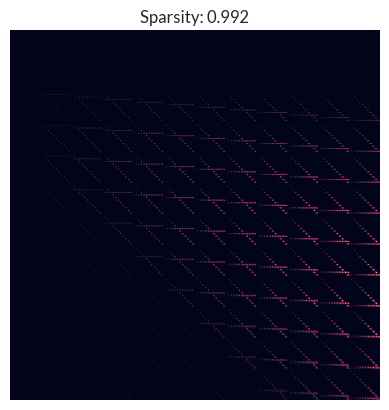

In [36]:
M, T = approximation(k_max, pars)
plt.imshow(M > 0, vmin = 0, vmax = 1)
plt.gca().axis("off")
t = plt.gca().set(title = f"Sparsity: {(M == 0).mean():.3f}")

In [62]:
(1.1**np.arange(0, np.log(1e6)/np.log(1.1))).astype(int)

array([     1,      1,      1,      1,      1,      1,      1,      1,
            2,      2,      2,      2,      3,      3,      3,      4,
            4,      5,      5,      6,      6,      7,      8,      8,
            9,     10,     11,     13,     14,     15,     17,     19,
           21,     23,     25,     28,     30,     34,     37,     41,
           45,     49,     54,     60,     66,     72,     80,     88,
           97,    106,    117,    129,    142,    156,    171,    189,
          207,    228,    251,    276,    304,    334,    368,    405,
          445,    490,    539,    593,    652,    717,    789,    868,
          955,   1051,   1156,   1271,   1399,   1538,   1692,   1862,
         2048,   2253,   2478,   2726,   2999,   3298,   3628,   3991,
         4390,   4830,   5313,   5844,   6428,   7071,   7778,   8556,
         9412,  10353,  11388,  12527,  13780,  15158,  16674,  18341,
        20176,  22193,  24413,  26854,  29539,  32493,  35743,  39317,
      

In [51]:
l = R_.shape[0]

sub1 = np.arange(1, 100)
sub2 = np.arange(100, l, 100)

np.concatenate([sub1, sub2])

array([      1,       2,       3, ...,  999800,  999900, 1000000])

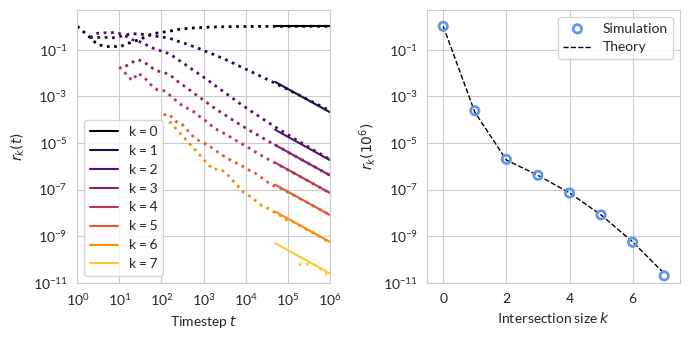

In [67]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


# figure for paper: four panels, one showing slope, one showing actual expected intersection sizes in graph, one showing theory, and one showing relative errors. 

# this is pretty good but we need to do some work with the legends and colorbars. 

theory_prop    = T.sum(axis = (0,1))
theory_prop    = theory_prop / theory_prop[0]
# theory_prop[1:] = theory_prop[1:] / timesteps 
# T = T / T[:,:,0].sum()   

q = theory_prop

k_min = 0
show_k_up_to = 8
import matplotlib.cm as cm
cmap = cm.inferno

fig, axarr = plt.subplots(1, 2, figsize = (7, 3.5))

# fig, axarr = plt.subplots(1, 4, figsize = (15, 4))


# 1. plot slopes
ax = axarr.ravel()[0]
R_ = R / R.sum(axis = 1)[:, None]
R_[R_ == 0] = np.nan

l = R_.shape[0]

decay = 1.4

subsample = (decay**np.arange(0, np.log(1e6)/np.log(decay))).astype(int)



for k in range(k_min, show_k_up_to): 
    try: 
        ax.plot(subsample, R_[    subsample, k], linestyle = ":", color = cmap(k/show_k_up_to), linewidth = 2)
    except: 
        pass

m_ = np.arange(50, 1000)*1000 + 1

for k in range(k_min, show_k_up_to): 
    if k == 0: 
        ax.plot(q[k]*m_, np.ones_like(m_), label = f"k = {k}", color = cmap(k/show_k_up_to))
    else:    
        ax.plot(m_, q[k]*1/m_, label = f"k = {k}", color = cmap(k/show_k_up_to))

ax.loglog()


ax.legend(frameon=True)

ax.set(xlim = (1, timesteps), ylim = (1e-11, 5), xlabel = r"Timestep $t$", ylabel = r"$r_{k}(t)$")


T_empirical = np.array([[[r[(i, j, k)] for k in range(k_max)] for j in range(k_max)] for i in range(k_max)])
T_empirical = T_empirical / T_empirical.sum()


empirical_prop = T_empirical.sum(axis = (0, 1)) / T_empirical.sum()
theory_prop    = T.sum(axis = (0,1))
theory_prop    = theory_prop / theory_prop[0]
theory_prop[1:] = theory_prop[1:] / timesteps 
ix = empirical_prop > 0


ax = axarr.ravel()[1]
ax.scatter(np.array(range(k_max))[np.where(ix)], empirical_prop[ix], label = "Simulation", edgecolors="cornflowerblue", facecolor = "none", zorder = 10, linewidth=2)
ax.plot(np.array(range(k_max))[np.where(ix)], theory_prop[ix], label = "Theory", color = "black", linewidth = 1, linestyle = "dashed")
ax.legend()

ax.semilogy()
ax.set(ylim = (1e-11, 5), xlim = (-0.5, 7.5))
# ax.xlim(-0.1, 10.5)
ax.set(xlabel = r"Intersection size $k$", ylabel = r"$r_k(10^6)$")

# this plot needs a separate colorbar

plt.tight_layout()

plt.savefig("../fig/intersection-asymptotics-2-panel.png", dpi = 300, bbox_inches = "tight")

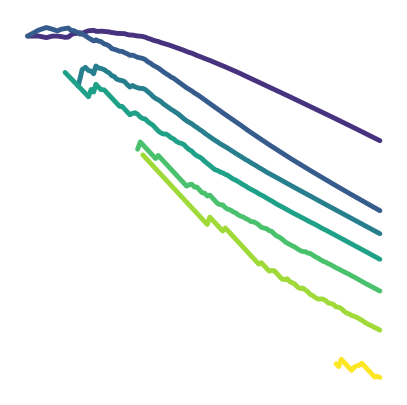

In [89]:
# arty version of first panel

k_min = 1
show_k_up_to = 8
import matplotlib.cm as cm
cmap = cm.viridis

fig, ax = plt.subplots(1, 1, figsize = (5, 5))

ax.axis("off")

R_ = R / R.sum(axis = 1)[:, None]
R_[R_ == 0] = np.nan

l = R_.shape[0]

decay = 1.1

subsample = (decay**np.arange(0, np.log(1e6)/np.log(decay))).astype(int)

for k in range(k_min, show_k_up_to): 
    try: 
        ax.plot(subsample, R_[    subsample, k],  color = cmap(k/(show_k_up_to - k_min)), linewidth = 3.5)
    except: 
        pass

ax.loglog()

plt.savefig("../fig/intersection-asymptotics-minimal.png", dpi = 300, bbox_inches = "tight")

## Fun Viz of Matrix Sparsity

This would be a nice candidate for making an art piece to commemorate the project! 

/var/folders/xn/wvbwvw0d6dx46h9_2bkrknnw0000gn/T/ipykernel_64814/1302115263.py:15: RuntimeWarning: divide by zero encountered in log
  M = np.log(M[k_max_*(k_max_+1):,k_max_*(k_max_+1):])


(np.float64(-0.5), np.float64(14.5), np.float64(14.5), np.float64(-0.5))

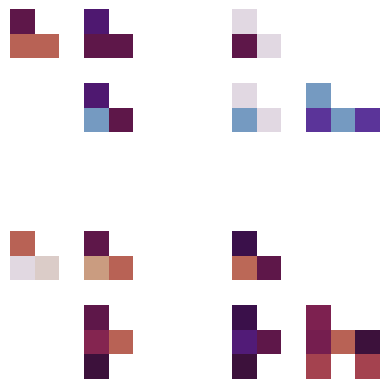

In [59]:
k_max_ = 3
pars = {
    "eta"   : 0.8, 
    "beta"  : np.zeros(k_max_),
    "gamma" : np.zeros(k_max_)
}

pars["beta"][0:7] = 1/7
pars["gamma"][0:7] = 1/7

eta, beta, gamma = pars["eta"], pars["beta"], pars["gamma"]

MC = m.MatrixConstructor(k_max_, pars)
M = MC.matrix_of_linear_map()
M = np.log(M[k_max_*(k_max_+1):,k_max_*(k_max_+1):])
plt.imshow(M, interpolation="none", cmap = "twilight")
plt.gca().axis("off")


In [64]:
k_max_ = 15
pars = {
    "eta"   : 0.6, 
    "beta"  : np.zeros(k_max_),
    "gamma" : np.zeros(k_max_)
}

pars["beta"][0:7] = 1/7
pars["gamma"][0:7] = 1/7

eta, beta, gamma = pars["eta"], pars["beta"], pars["gamma"]

MC = m.MatrixConstructor(k_max_, pars)
M = MC.matrix_of_linear_map()
# M = np.log(M[k_max_*(k_max_+1):,k_max_*(k_max_+1):])
M = M[k_max_*(k_max_+1):,k_max_*(k_max_+1):]
# plt.imshow(M, interpolation="none", cmap = "twilight")
# plt.gca().axis("off")


# M, T = approximation(k_max_, pars)


/Users/philchodrow/Desktop/HyperGraph/code/src/analytic-intersection-asymptotics.py:259: RuntimeWarning: invalid value encountered in divide
  return binom(n_success, k_success)*binom(n - n_success, k - k_success)/binom(n, k)


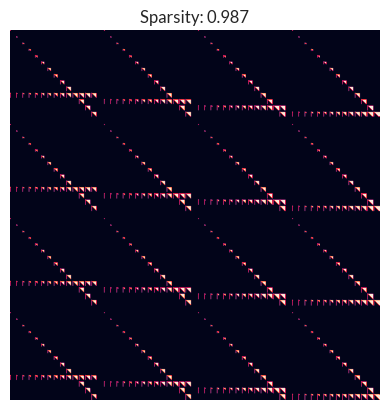

In [69]:
plt.imshow(M[(150*k_max_):, (150*k_max_):] > 0, vmin = 0, vmax = 1)
plt.gca().axis("off")
t = plt.gca().set(title = f"Sparsity: {(M == 0).mean():.3f}")